# Lab 6: Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

### 1. Aim
To evaluate and compare the performance of Logistic Regression and K Nearest Neighbors (KNN) classifiers on a real-world dataset.

### 2. Objectives
1. To preprocess the dataset and perform exploratory data analysis.
2. To implement Logistic Regression and KNN classifiers.
3. To find the optimal K value for the KNN classifier.
4. To evaluate models using accuracy, precision, recall, and F1-score.
5. To compare the models visually and quantitatively.

### 3. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

### 4. Load Dataset

In [2]:
data = load_breast_cancer()

### 5. Dataset/DataFrame Preparation

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 6. Dataset Shape

In [4]:
print('Dataset Shape:', df.shape)

Dataset Shape: (569, 31)


### 7. Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 8. Feature Names

In [6]:
print('Feature Names:', data.feature_names)

Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


### 9. Target Names

In [7]:
print('Target Names:', data.target_names)

Target Names: ['malignant' 'benign']


### 10. Exploratory Data Analysis

In [8]:
print('Starting EDA...')

Starting EDA...


### 11. Statistical Summary

In [9]:
display(df.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### 12. Class Distribution

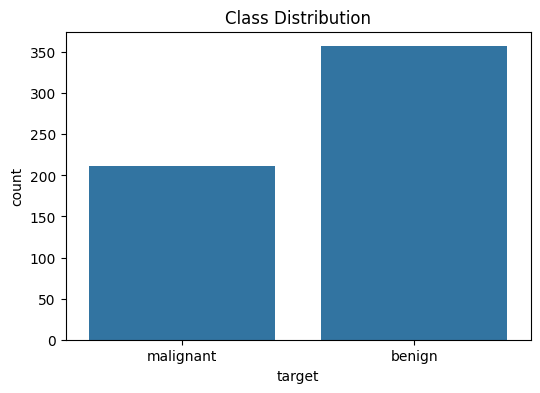

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Class Distribution')
plt.xticks(ticks=[0, 1], labels=data.target_names)
plt.show()

### 13. Missing Value Analysis

In [11]:
print('Missing Values:\n', df.isnull().sum().sum())

Missing Values:
 0


### 14. Correlation Heatmap

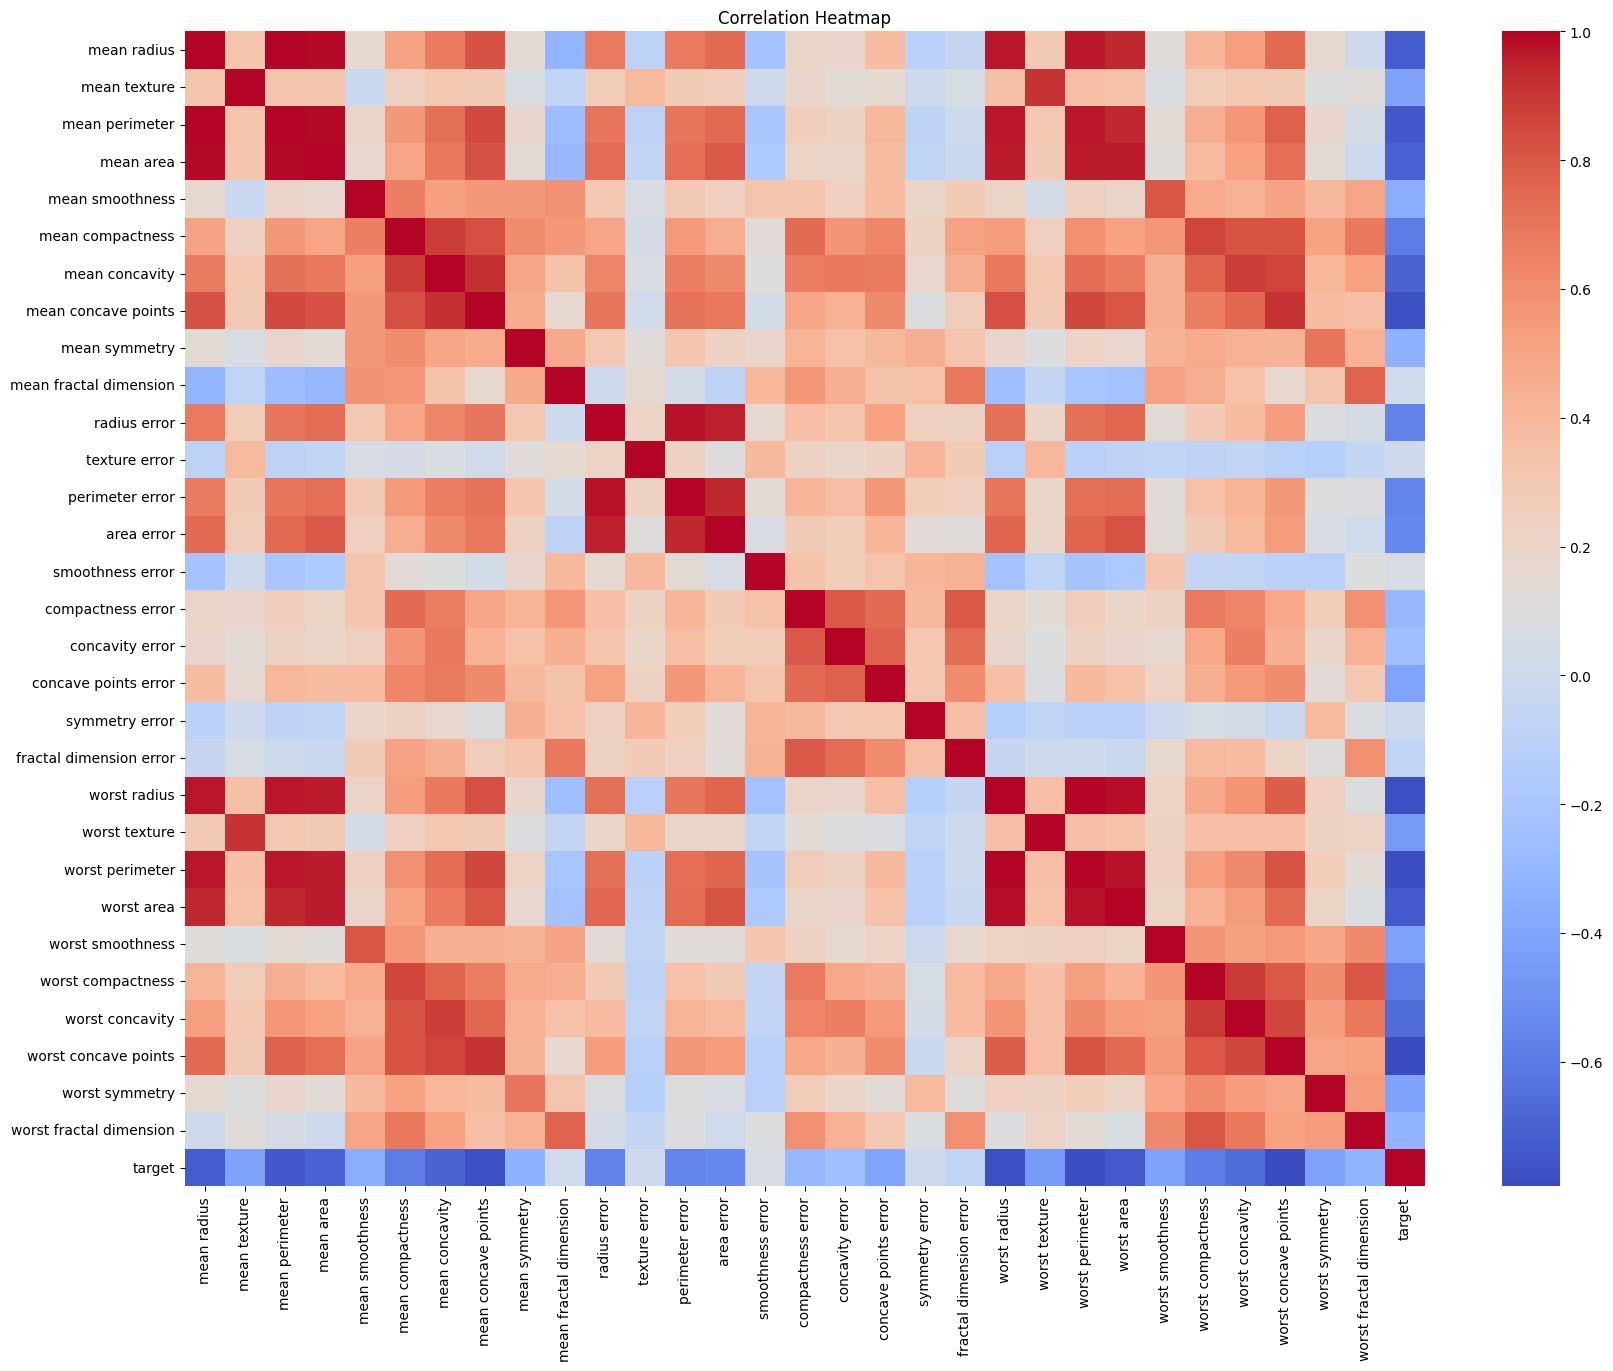

In [12]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 15. Histograms of Selected Features

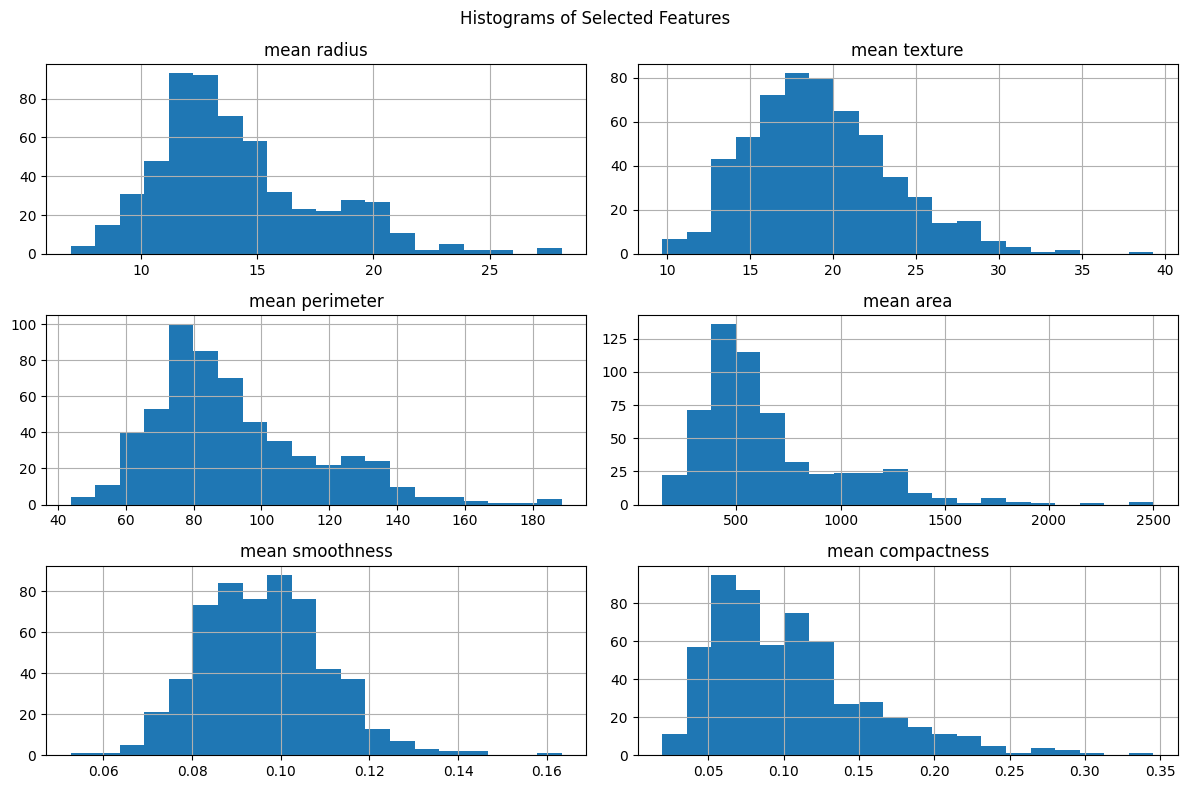

In [13]:
features_to_plot = df.columns[:6]
df[features_to_plot].hist(bins=20, figsize=(12, 8))
plt.suptitle('Histograms of Selected Features')
plt.tight_layout()
plt.show()

### 16. Boxplots for Outlier Detection

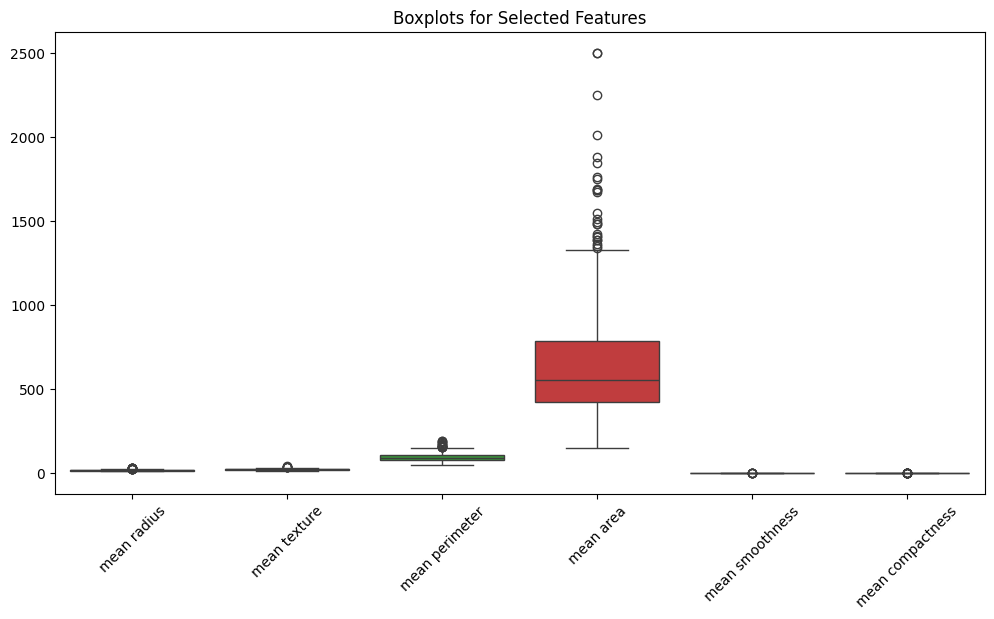

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[features_to_plot])
plt.title('Boxplots for Selected Features')
plt.xticks(rotation=45)
plt.show()

### 17. Pairplot of Selected Features

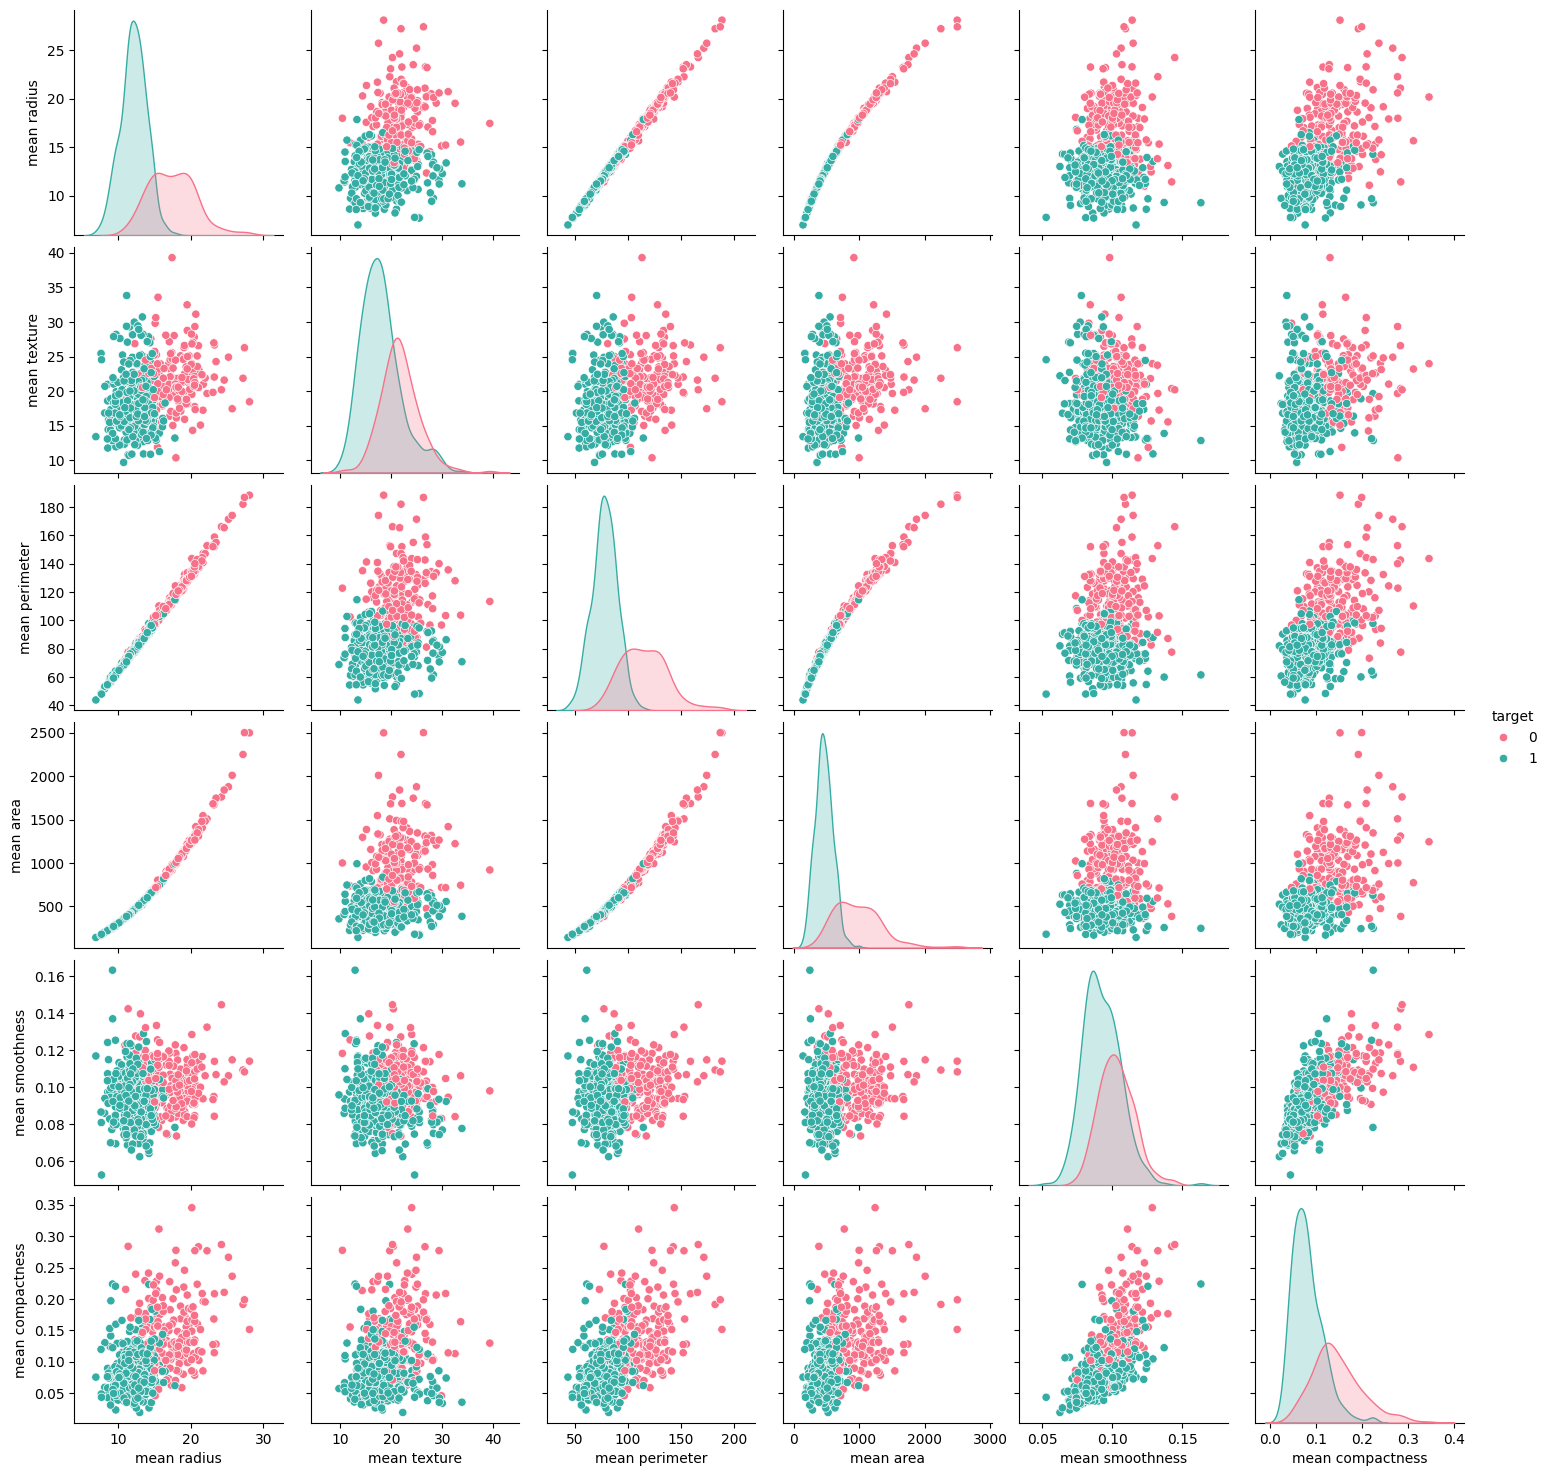

In [15]:
sns.pairplot(df[features_to_plot.tolist() + ['target']], hue='target', palette='husl')
plt.show()

### 18. Data Preprocessing

In [16]:
X = df.drop('target', axis=1)
y = df['target']

### 19. Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


### 20. Feature Scaling

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 21. Logistic Regression Model

In [19]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

/Users/mani/Documents/2547261_ML-Lab_CIA1/venv2/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv2/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv2/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv2/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv2/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: Runti

LogisticRegression(max_iter=1000, random_state=42)

### 22. Logistic Regression Predictions

In [20]:
lr_preds = lr_model.predict(X_test_scaled)
print('Logistic Regression Predictions sample:', lr_preds[:10])

Logistic Regression Predictions sample: [1 0 0 1 1 0 0 0 1 1]


/Users/mani/Documents/2547261_ML-Lab_CIA1/venv2/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv2/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mani/Documents/2547261_ML-Lab_CIA1/venv2/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### 23. KNN Model

In [21]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

### 24. KNN Accuracy for Multiple K Values

In [22]:
k_values = list(range(1, 21))
knn_accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_preds = knn.predict(X_test_scaled)
    knn_accuracies.append(accuracy_score(y_test, knn_preds))
print('Accuracies for different K:', knn_accuracies)

Accuracies for different K: [0.9385964912280702, 0.9385964912280702, 0.9473684210526315, 0.956140350877193, 0.9473684210526315, 0.956140350877193, 0.9473684210526315, 0.956140350877193, 0.9649122807017544, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.9473684210526315, 0.956140350877193, 0.9473684210526315, 0.956140350877193]


### 25. KNN Accuracy vs K Plot

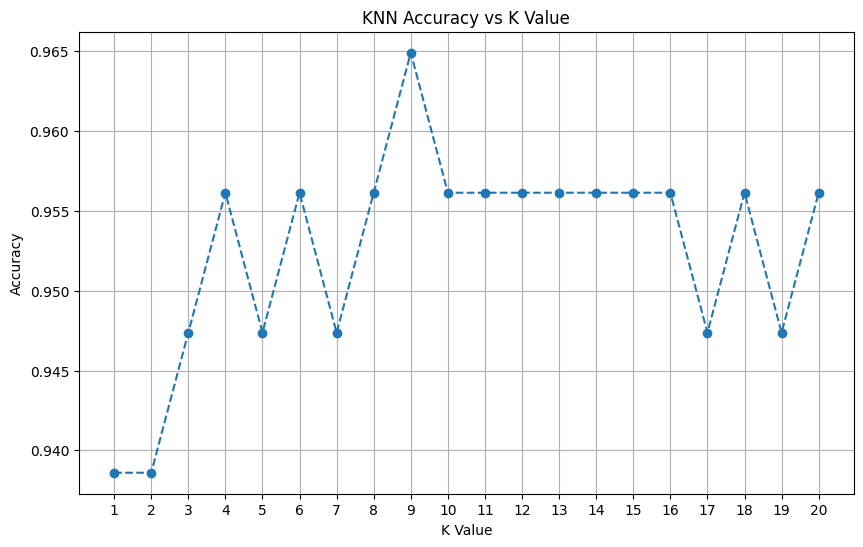

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_accuracies, marker='o', linestyle='--')
plt.title('KNN Accuracy vs K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

### 26. Best K Selection

In [24]:
best_k = k_values[np.argmax(knn_accuracies)]
print(f'Best K value is {best_k} with accuracy {max(knn_accuracies):.4f}')
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
best_knn_preds = best_knn.predict(X_test_scaled)

Best K value is 9 with accuracy 0.9649


### 27. Model Evaluation Function

In [25]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f'--- {model_name} Evaluation ---')
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall: {rec:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print('\nClassification Report:\n', classification_report(y_true, y_pred))
    return acc, prec, rec, f1

### 28. Logistic Regression Evaluation

In [26]:
lr_metrics = evaluate_model(y_test, lr_preds, 'Logistic Regression')

--- Logistic Regression Evaluation ---
Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1 Score: 0.9790

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### 29. KNN Evaluation

In [27]:
knn_metrics = evaluate_model(y_test, best_knn_preds, 'KNN')

--- KNN Evaluation ---
Accuracy: 0.9649
Precision: 0.9718
Recall: 0.9718
F1 Score: 0.9718

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



### 30. Confusion Matrices

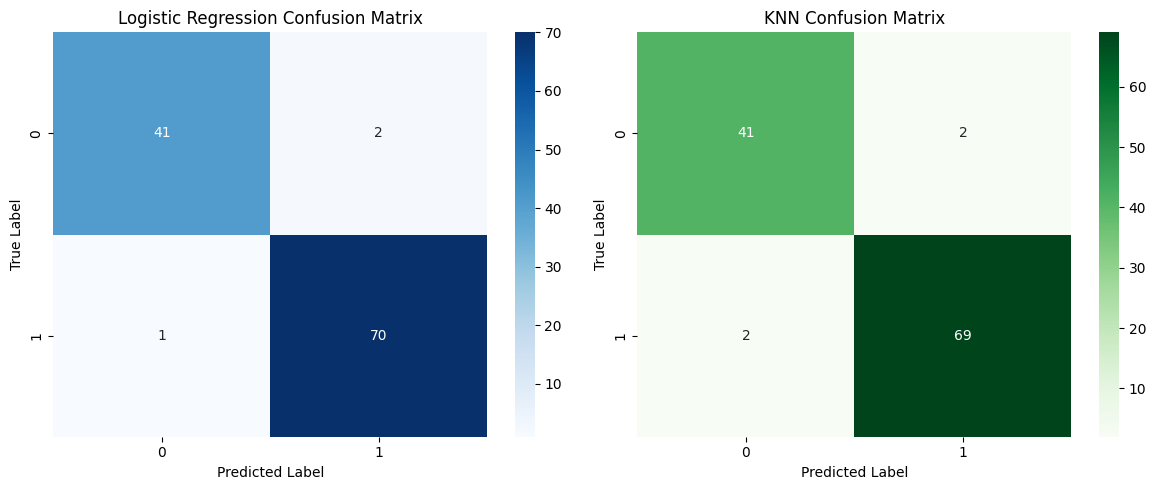

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

sns.heatmap(confusion_matrix(y_test, best_knn_preds), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('KNN Confusion Matrix')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### 31. Performance Comparison DataFrame

In [29]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN'],
    'Accuracy': [lr_metrics[0], knn_metrics[0]],
    'Precision': [lr_metrics[1], knn_metrics[1]],
    'Recall': [lr_metrics[2], knn_metrics[2]],
    'F1 Score': [lr_metrics[3], knn_metrics[3]]
})
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.973684,0.972222,0.985915,0.979021
1,KNN,0.964912,0.971831,0.971831,0.971831


### 32. Visual Performance Comparison

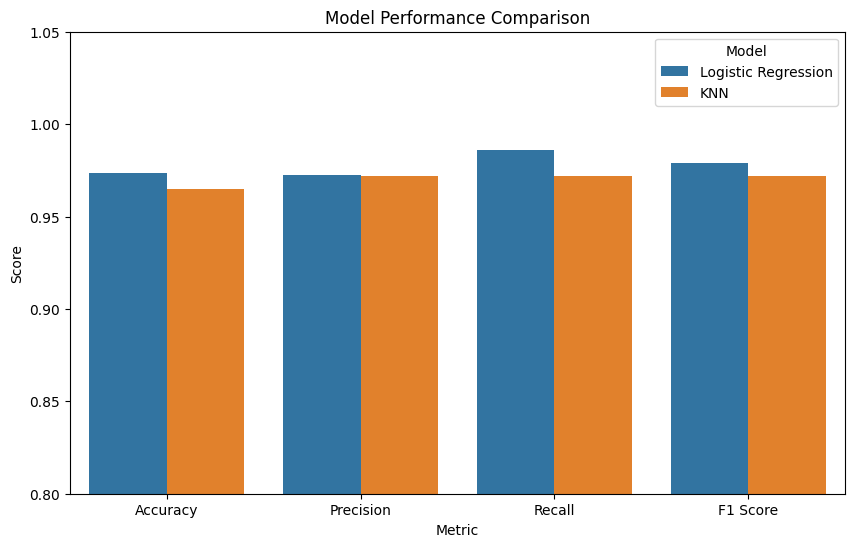

In [30]:
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted)
plt.title('Model Performance Comparison')
plt.ylim(0.8, 1.05)
plt.show()

### 33. Results
The comparison shows the relative performance of Logistic Regression vs KNN on the dataset.

### 34. Conclusion
Both Logistic Regression and KNN perform exceptionally well on the Breast Cancer dataset. The optimal K for KNN was found, and performance metrics were visualized for a complete comparison.

### 35. Learning Outcomes
- Successfully preprocessed and visualized a real-world dataset.
- Built and evaluated Logistic Regression and KNN models.
- Visualized and compared multiple model metrics effectively.